# Call My Maybe Telecomunicaciones

## Introducción
### Identificación de Operadores Ineficaces en CallMeMaybe

### Objetivo

CallMeMaybe desea desarrollar una herramienta que permita detectar operadores ineficaces.
Se considera que un operador puede ser ineficaz cuando:

- Presenta una alta cantidad de llamadas perdidas.
- Tiene tiempos de espera elevados.
- Realiza pocas llamadas salientes cuando su función lo requiere.

El objetivo de este proyecto es:

1. Realizar un análisis exploratorio de datos.
2. Detectar operadores potencialmente ineficaces.
3. Validar estadísticamente los resultados mediante pruebas de hipótesis.

### Librerias

In [65]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

pd.set_option('display.max_columns', None)

### Carga De Datos

In [66]:
telecom = pd.read_csv('telecom_dataset_new.csv')
clients = pd.read_csv('telecom_clients.csv')

### Inspeccion Inicial 

In [67]:
display(telecom.head())
display(clients.head())

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


In [68]:
telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB


In [69]:
telecom.describe(include='all')

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
count,53902.000000,53902,53902,53785,45730.000000,53902,53902.000000,53902.000000,53902.000000
unique,NaN,119,2,2,NaN,2,NaN,NaN,NaN
top,NaN,2019-11-25 00:00:00+03:00,out,False,NaN,False,NaN,NaN,NaN
freq,NaN,1220,31917,47621,NaN,30334,NaN,NaN,NaN
mean,167295.344477,NaN,NaN,NaN,916535.993002,NaN,16.451245,866.684427,1157.133297
std,598.883775,NaN,NaN,NaN,21254.123136,NaN,62.917170,3731.791202,4403.468763
min,166377.000000,NaN,NaN,NaN,879896.000000,NaN,1.000000,0.000000,0.000000
25%,166782.000000,NaN,NaN,NaN,900788.000000,NaN,1.000000,0.000000,47.000000
50%,167162.000000,NaN,NaN,NaN,913938.000000,NaN,4.000000,38.000000,210.000000
75%,167819.000000,NaN,NaN,NaN,937708.000000,NaN,12.000000,572.000000,902.000000


In [70]:
clients.describe(include='all')

,user_id,tariff_plan,date_start
count,732.000000,732,732
unique,NaN,3,73
top,NaN,C,2019-09-24
freq,NaN,395,24
mean,167431.927596,NaN,NaN
std,633.810383,NaN,NaN
min,166373.000000,NaN,NaN
25%,166900.750000,NaN,NaN
50%,167432.000000,NaN,NaN
75%,167973.000000,NaN,NaN


### Limpieza y preparación
Conversión de fechas

In [71]:
telecom['date'] = pd.to_datetime(telecom['date'])
clients['date_start'] = pd.to_datetime(clients['date_start'])

Valores ausentes

In [72]:
telecom.isna().sum()

user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

In [73]:
clients.isna().sum()

user_id        0
tariff_plan    0
date_start     0
dtype: int64

### Duplicados

In [74]:
print("Duplicados telecom:", telecom.duplicated().sum())
print("Duplicados clientes:", clients.duplicated().sum())

Duplicados telecom: 4900
Duplicados clientes: 0


In [75]:
telecom = telecom.drop_duplicates()
clients = clients.drop_duplicates()

### reación de variables
#### Tiempo de espera
La diferencia entre duración total y duración real representa el tiempo de espera.

In [76]:
telecom['waiting_time'] = (
    telecom['total_call_duration']
    - telecom['call_duration']
)

In [77]:
telecom['waiting_time'].describe()

count    49002.000000
mean       290.276111
std       1132.155291
min          0.000000
25%         17.000000
50%         55.000000
75%        200.000000
max      46474.000000
Name: waiting_time, dtype: float64

### Análisis Exploratorio de Datos (EDA)
Distribución de llamadas

In [78]:
telecom['direction'].value_counts()

direction
out    28999
in     20003
Name: count, dtype: int64

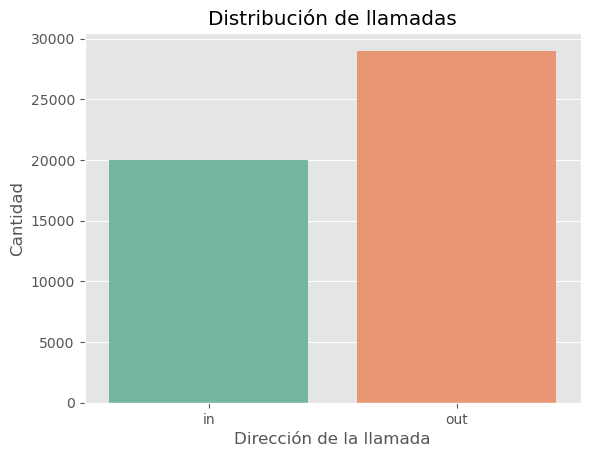

In [79]:
colores = sns.color_palette("Set2", n_colors=telecom['direction'].nunique())

sns.countplot(
    data=telecom,
    x='direction',
    hue='direction',
    palette=colores,
    legend=False 
)

plt.title('Distribución de llamadas')
plt.xlabel('Dirección de la llamada')
plt.ylabel('Cantidad')
plt.show()

Llamadas internas vs externas

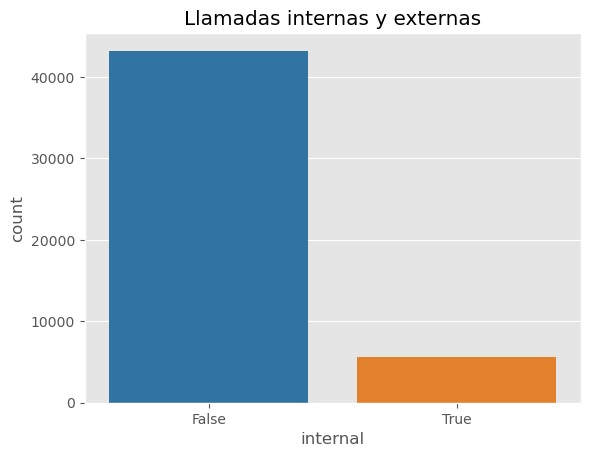

In [80]:
sns.countplot(
    data=telecom,
    x='internal',
    palette=['#1f77b4', '#ff7f0e']  # Azul y naranja
)

plt.title('Llamadas internas y externas')
plt.show()


Llamadas perdidas

In [81]:
telecom['is_missed_call'].value_counts()

is_missed_call
False    27549
True     21453
Name: count, dtype: int64

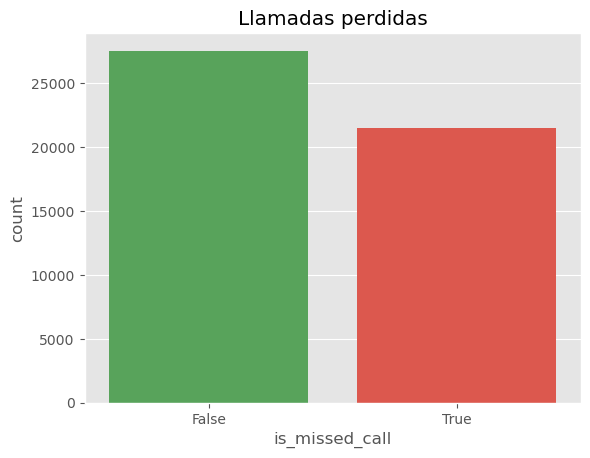

In [82]:
sns.countplot(
    data=telecom,
    x='is_missed_call',
    hue='is_missed_call',
    palette=['#4CAF50', '#F44336'],  # Verde y rojo
    legend=False
)

plt.title('Llamadas perdidas')
plt.show()

Duración de llamadas

Text(0, 0.5, 'Frecuencia')

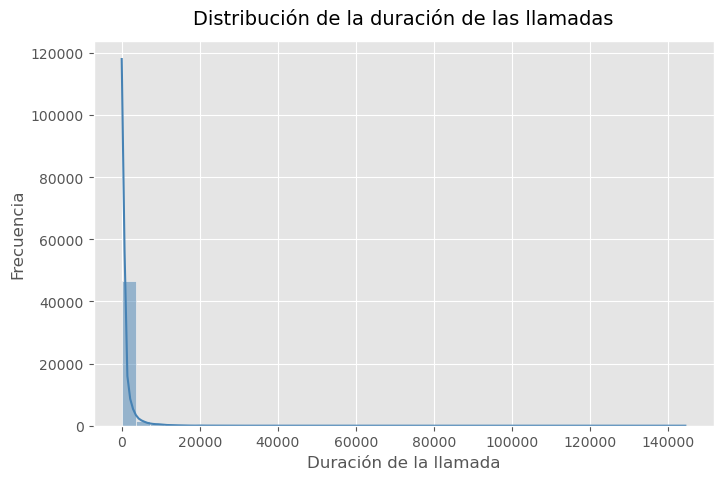

In [105]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=telecom,
    x='call_duration',
    bins=40,
    kde=True,
    color='steelblue'
)

plt.title('Distribución de la duración de las llamadas', fontsize=14, pad=12)
plt.xlabel('Duración de la llamada')
plt.ylabel('Frecuencia')

Tiempo de espera

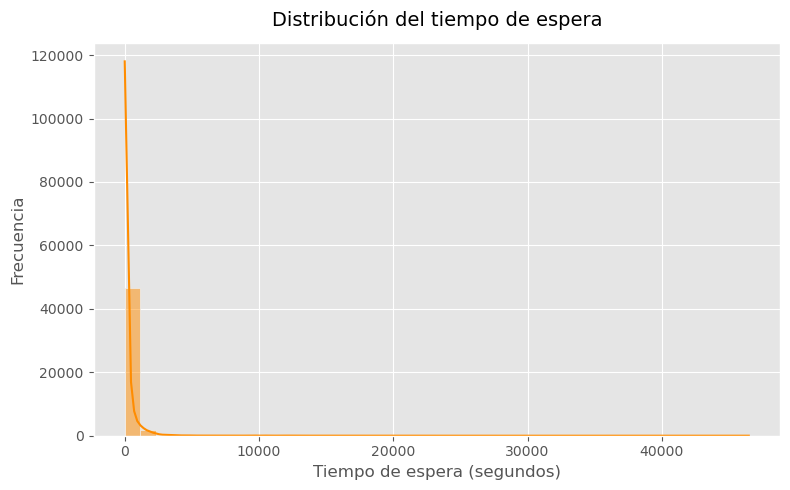

In [106]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=telecom,
    x='waiting_time',
    bins=40,
    kde=True,
    color='darkorange'
)

plt.title('Distribución del tiempo de espera', fontsize=14, pad=12)
plt.xlabel('Tiempo de espera (segundos)')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### Correlaciones

Seleccionamos variables numéricas.

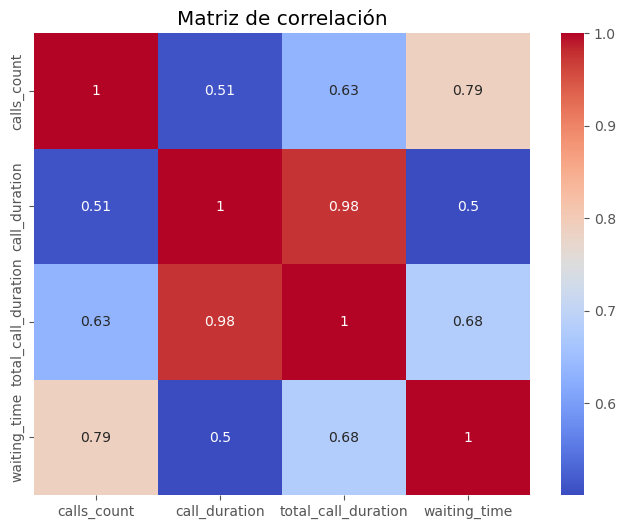

In [85]:
numeric_cols = [
    'calls_count',
    'call_duration',
    'total_call_duration',
    'waiting_time'
]

corr = telecom[numeric_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Matriz de correlación')
plt.show()

### Análisis por operador
Métricas clave

In [86]:
operator_stats = telecom.groupby('operator_id').agg({
    'calls_count':'sum',
    'call_duration':'mean',
    'waiting_time':'mean'
}).reset_index()

operator_stats.head()

,operator_id,calls_count,call_duration,waiting_time
0,879896.0,930,545.829060,104.914530
1,879898.0,7313,1133.881057,457.696035
2,880020.0,45,112.250000,14.000000
3,880022.0,197,216.385714,53.971429
4,880026.0,2232,842.450549,121.978022


Llamadas perdidas por operador

In [87]:
missed_calls = (
    telecom[telecom['is_missed_call']]
    .groupby('operator_id')['calls_count']
    .sum()
    .reset_index()
)

missed_calls.columns = [
    'operator_id',
    'missed_calls'
]

Llamadas salientes

In [88]:
out_calls = (
    telecom[telecom['direction']=='out']
    .groupby('operator_id')['calls_count']
    .sum()
    .reset_index()
)

out_calls.columns = [
    'operator_id',
    'out_calls'
]

Unificación

In [89]:
operator_stats = (
    operator_stats
    .merge(
        missed_calls,
        on='operator_id',
        how='left'
    )
    .merge(
        out_calls,
        on='operator_id',
        how='left'
    )
)

operator_stats.fillna(0, inplace=True)

### Identificación de operadores ineficaces
Escalado

In [90]:
features = [
    'missed_calls',
    'waiting_time',
    'out_calls'
]

data = operator_stats[features].copy()

In [91]:
data['out_calls'] = -data['out_calls']


Invertimos llamadas salientes porque pocas llamadas indican peor desempeño.

In [92]:
scaler = StandardScaler()

scaled = scaler.fit_transform(data)

Índice de ineficiencia

In [93]:
operator_stats['inefficiency_score'] = (
    scaled[:,0]
    + scaled[:,1]
    + scaled[:,2]
)

Umbral

Operadores en el 75 percentil superior.

In [94]:
threshold = (
    operator_stats['inefficiency_score']
    .quantile(0.75)
)

In [95]:
inefficient = operator_stats[
    operator_stats['inefficiency_score']
    >= threshold
]

In [96]:
inefficient.sort_values(
    'inefficiency_score',
    ascending=False
).head(20)

,operator_id,calls_count,call_duration,waiting_time,missed_calls,out_calls,inefficiency_score
583,929428.0,23754,4263.353846,5478.123077,19118.0,23754.0,16.943810
551,925922.0,20021,11353.178082,5805.027397,9258.0,19603.0,11.332455
29,885890.0,60221,13204.703557,5703.565217,23807.0,58977.0,8.566036
317,908640.0,14239,6018.697674,3537.860465,8164.0,14239.0,7.904390
582,929426.0,11189,4308.080645,3338.790323,6347.0,11189.0,7.169449
28,885876.0,59429,15420.328622,4838.459364,23330.0,58437.0,6.676606
448,919364.0,4820,2397.756098,2804.390244,2688.0,4820.0,5.506538
843,945278.0,4001,4915.818182,2965.590909,1764.0,4001.0,5.390913
847,945286.0,6880,2365.209677,2178.177419,3626.0,6880.0,4.275176
853,945302.0,6138,4621.257143,1934.671429,3184.0,6138.0,3.711464


Visualización

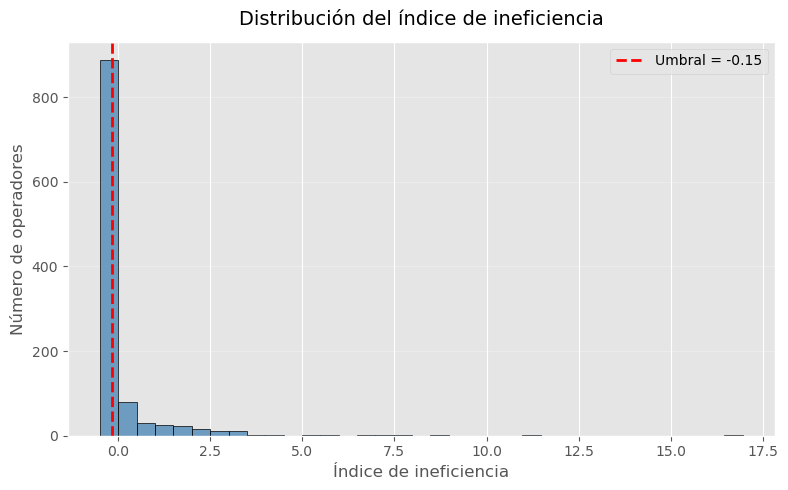

In [107]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=operator_stats,
    x='inefficiency_score',
    bins=35,
    color='steelblue',
    edgecolor='black'
)

plt.axvline(
    x=threshold,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Umbral = {threshold:.2f}'
)

plt.title('Distribución del índice de ineficiencia', fontsize=14, pad=12)
plt.xlabel('Índice de ineficiencia')
plt.ylabel('Número de operadores')

plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

### Prueba de hipótesis 1
#### Hipótesis
H0: Los operadores ineficaces y eficientes tienen el mismo tiempo promedio de espera.

H1: Los operadores ineficaces tienen mayor tiempo promedio de espera.

Preparación

In [98]:
operator_stats['group'] = np.where(
    operator_stats['inefficiency_score'] >= threshold,
    'inefficient',
    'efficient'
)

In [99]:
inefficient_wait = operator_stats[
    operator_stats['group']=='inefficient'
]['waiting_time']

efficient_wait = operator_stats[
    operator_stats['group']=='efficient'
]['waiting_time']

Test

In [100]:
alpha = 0.05

results = stats.ttest_ind(
    inefficient_wait,
    efficient_wait,
    equal_var=False
)

print(results)

TtestResult(statistic=np.float64(13.817427491223055), pvalue=np.float64(2.852086599290612e-33), df=np.float64(272.4420861079243))


In [101]:
if results.pvalue < alpha:
    print("Rechazamos H0")
else:
    print("No rechazamos H0")

Rechazamos H0


### Prueba de hipótesis 2
#### Hipótesis
H0: La tasa de llamadas perdidas es igual para ambos grupos.

H1: Los operadores ineficaces tienen más llamadas perdidas.

In [102]:
inefficient_missed = operator_stats[
    operator_stats['group']=='inefficient'
]['missed_calls']

efficient_missed = operator_stats[
    operator_stats['group']=='efficient'
]['missed_calls']

In [103]:
results = stats.ttest_ind(
    inefficient_missed,
    efficient_missed,
    equal_var=False
)

print(results)

TtestResult(statistic=np.float64(5.554731782498952), pvalue=np.float64(6.606167313954743e-08), df=np.float64(272.54032872377104))


In [104]:
if results.pvalue < alpha:
    print("Rechazamos H0")
else:
    print("No rechazamos H0")

Rechazamos H0


## Conclusiones Finales
### Conclusiones

#### Hallazgos principales

- Se identificaron operadores con niveles significativamente superiores de llamadas perdidas.
- Los operadores catalogados como ineficaces presentan tiempos de espera considerablemente mayores.
- También muestran una menor actividad en llamadas salientes.
- El índice de ineficiencia permitió detectar al grupo con peor desempeño operativo.

#### Resultados estadísticos

- La prueba de hipótesis confirmó diferencias significativas en los tiempos de espera.
- También se encontraron diferencias significativas en la cantidad de llamadas perdidas.

#### Recomendaciones

- Capacitación específica para operadores identificados como ineficaces.
- Implementación de alertas automáticas basadas en llamadas perdidas y tiempos de espera.
- Seguimiento continuo mediante dashboards operativos.

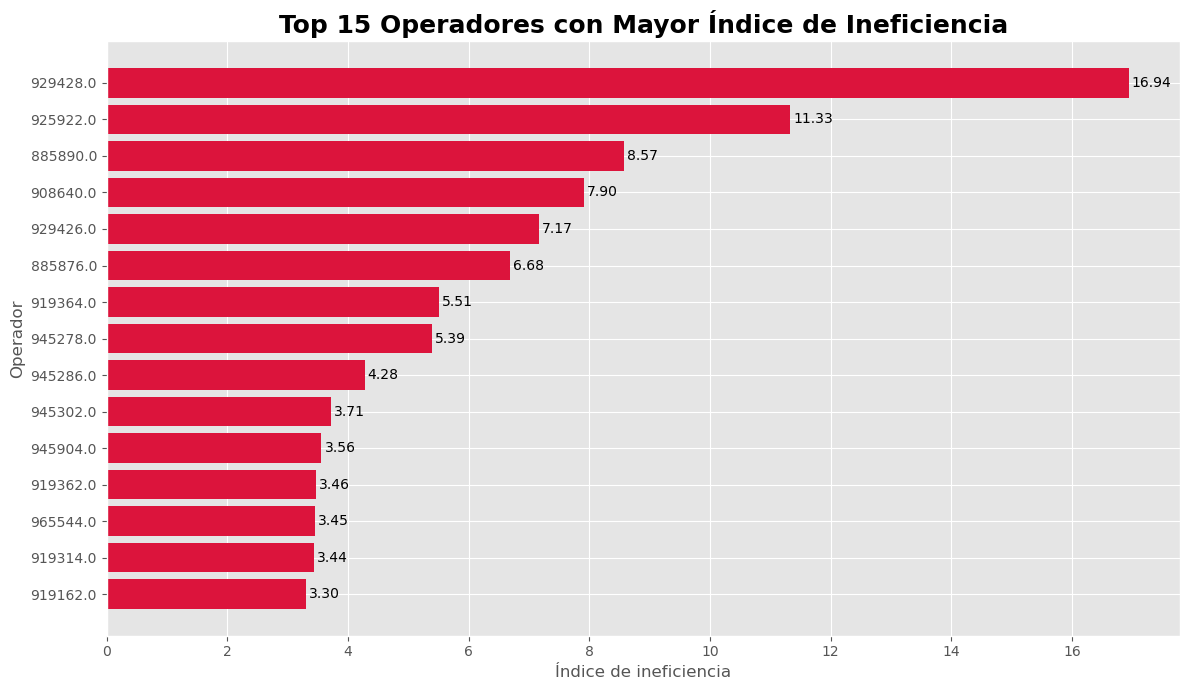

In [108]:
top15 = (
    operator_stats
    .sort_values('inefficiency_score', ascending=False)
    .head(15)
)

plt.figure(figsize=(12,7))

colors = ['crimson' if x >= threshold else 'steelblue'
          for x in top15['inefficiency_score']]

plt.barh(
    top15['operator_id'].astype(str),
    top15['inefficiency_score'],
    color=colors
)

plt.gca().invert_yaxis()

plt.title(
    'Top 15 Operadores con Mayor Índice de Ineficiencia',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Índice de ineficiencia')
plt.ylabel('Operador')

for i, v in enumerate(top15['inefficiency_score']):
    plt.text(v + 0.05, i, f'{v:.2f}', va='center')

plt.tight_layout()
plt.show()